In [12]:
import requests
import pandas as pd
import yfinance as yf
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import openpyxl
from openpyxl.styles import Font

In [ ]:
# Cell downloads, cleans the data and manipulates it into a more useful form  (Uses requests, pandas, yfinance, numpy)

fred_url = "https://api.stlouisfed.org/fred/series/observations"

# Fetches UK Interest Rates
uk_params = {"series_id": "IUDSOIA",
             "api_key": "", 
             "file_type": "json"}

uk_response = requests.get(fred_url, params = uk_params)

# Unpacks data to a dictionary and extracts data
uk_data = uk_response.json()
uk_observations = uk_data["observations"]
# Turns the extracted data into dataframe and cleans data
uk_df = pd.DataFrame(uk_observations)
uk_df = uk_df[["date", "value"]].copy()
# Turns date column into date type and sets it as the index of the df
uk_df["date"] = pd.to_datetime(uk_df["date"])
uk_df = uk_df.set_index("date")
# Turns the value column from char to numbers for calculations
uk_df["value"] = pd.to_numeric(uk_df["value"], errors="coerce")
uk_df.columns = ["UK_Rate"]

# Fetches US Interest Rates
us_params = {"series_id": "FEDFUNDS",
          "api_key": "",
          "file_type": "json"}

us_response = requests.get(fred_url, params = us_params)

us_data = us_response.json()
us_observations = us_data["observations"]

# Same as UK DF
us_df = pd.DataFrame(us_observations)
us_df = us_df[["date", "value"]].copy()
us_df["date"] = pd.to_datetime(us_df["date"])
us_df = us_df.set_index("date")
us_df["value"] = pd.to_numeric(us_df["value"], errors="coerce")
us_df = us_df.rename(columns={"value": "US_Rate"})

# Download data using yfinance
fx_data = yf.download(["GBPUSD=X", "^GSPC"], start="2020-01-01")
fx_data = fx_data[["Close"]].copy()
fx_data.columns = ["GBP_USD", "S&P_500"]

# Combines 2 datasets horizontally then cleans data
macro_data = pd.concat([us_df, uk_df, fx_data], axis=1, join="outer", sort=True) 
macro_data = macro_data.ffill()
macro_data = macro_data.dropna()

# Calcuate percentage change to turn data from non-stationary to stationary so we can use OLS 
macro_data["FX_Returns"] = macro_data["GBP_USD"].pct_change()
macro_data["Rate_Diff"] = macro_data["US_Rate"] - macro_data["UK_Rate"]
macro_data["S&P_500_Returns"] = macro_data["S&P_500"].pct_change()

# Creates a column where 1 indicts a positive FX_Return and 0 is for values of <= 0 
macro_data["Direction"] = np.where(macro_data["FX_Returns"] > 0, 1, 0)

# Shifts data to create a lagged column so we use yesterdays data to predict today's fx return for OLS
macro_data["Lagged_Rate_Diff"] = macro_data["Rate_Diff"].shift(1)
macro_data["Lagged_S&P_500_Returns"] = macro_data["S&P_500_Returns"].shift(1)

macro_data = macro_data.dropna()

print(macro_data.tail(10))
# print(monthly_data)


[*********************100%***********************]  2 of 2 completed

            US_Rate  UK_Rate   GBP_USD      S&P_500  FX_Returns  Rate_Diff  \
2026-08-04     3.63   3.7318  1.342700  7736.520020   -0.004791    -0.1018   
2026-08-05     3.63   3.7313  1.345098  7723.549805    0.001786    -0.1013   
2026-08-06     3.63   3.7323  1.346965  7709.959961    0.001387    -0.1023   
2026-08-07     3.63   3.7318  1.345533  7757.640137   -0.001063    -0.1018   
2026-08-10     3.63   3.7315  1.349071  7753.109863    0.002629    -0.1015   
2026-08-11     3.63   3.7315  1.351132  7728.200195    0.001528    -0.1015   
2026-08-12     3.63   3.7310  1.350986  7748.500000   -0.000108    -0.1010   
2026-08-13     3.63   3.7310  1.349783  7798.990234   -0.000891    -0.1010   
2026-08-14     3.63   3.7310  1.349073  7785.759766   -0.000526    -0.1010   
2026-08-16     3.63   3.7310  1.353290  7785.759766    0.003126    -0.1010   

            S&P_500_Returns  Direction  Lagged_Rate_Diff  \
2026-08-04         0.017896          0           -0.1021   
2026-08-05        -0.

In [14]:
# Maths to check if data is stationary or not (Modules: statsmodel.tsa.stattools)

raw_test = adfuller(macro_data["GBP_USD"])
raw_p_value = raw_test[1]

print(raw_p_value)

returns_test = adfuller(macro_data["FX_Returns"])
returns_p_value = returns_test[1]

print(returns_p_value)

0.31428562132560656
2.7796968699359312e-30


In [15]:
# OLS Cell (uses pandas and statsmodel.api)
# Helps to check if variables are statistically significant relationship on FX returns before logistic regression
x = macro_data[["Lagged_Rate_Diff", "Lagged_S&P_500_Returns"]]
x = sm.add_constant(x)

y = macro_data["FX_Returns"]

results = sm.OLS(y, x).fit()
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:             FX_Returns   R-squared:                       0.105
Model:                            OLS   Adj. R-squared:                  0.104
Method:                 Least Squares   F-statistic:                     102.4
Date:                Sun, 16 Aug 2026   Prob (F-statistic):           8.58e-43
Time:                        18:10:21   Log-Likelihood:                 6731.8
No. Observations:                1748   AIC:                        -1.346e+04
Df Residuals:                    1745   BIC:                        -1.344e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -0

In [16]:
# Logistic Regression Cell (Modules: sklearn.model_selection, sklearn.linear_model, sklearn.metrics)

x_logistic = macro_data[["Lagged_Rate_Diff", "Lagged_S&P_500_Returns"]]
y_logistic = macro_data["Direction"]

# Reminder: Essentially train_test_split() function segments data you input and returns 4 items (2 dataframes and 2 series).
#           test_size sets the percentage of data to be used for training and for testing so 0.2 here means 20% of data to be used
#           for testing and 80% for training.

#           x_train, x_test, y_train, y_test are just variables which stores data outputted to train and test the model
#           For example: x_train stores the 80% of x_logistic which is the inputted dependent variable
#                        y_train stores 80% of y_logistic which is the dependent variable
#           On the other hand x_test and y_test is the remaining 20% of x_logistic and y_logistic 
#           They are used to check how accurate the model is with its predictions 

# More simply imagine it's like a maths textbook with questions and solutions and test_size is the percentage of those questions the teacher
# wants to save for the exam. In this case 80% of the "questions and solutions" are used to teach the model
# while the remining 20% is for the exam to test how accurate the model actually is.

# Also shuffle = False as we don't want our model to see future data so we keep it in order
x_train, x_test, y_train, y_test = train_test_split(x_logistic, y_logistic, test_size=0.2, shuffle=False)

# Initialises the model
model = LogisticRegression()
# Trains the model with data and results
model.fit(x_train, y_train)
# Gives the model unseen data to test it's prediction
predictions = model.predict(x_test)
# Compares prediction with the true values (y_test). It's the percentage of correct predictions our model made
accuracy = round(accuracy_score(y_test, predictions) * 100, 1)
print(f"Model Accuracy: {accuracy}%")

# Percentage of days going up to see if model is beating a random guess of buying everyday
daily_buy = round(y_test.mean() * 100, 1)
print(f"Only Buy Accuracy: {daily_buy}% \nOnly Sell Accuracy: {100-daily_buy}%")

# This line is done in order to avoid the warning for possible order mismatch so we apply the column name it expects
today_data = pd.DataFrame([[macro_data["Rate_Diff"].iloc[-1], macro_data["S&P_500_Returns"].iloc[-1]]], columns=x_logistic.columns)
tomorrow_direction = model.predict(today_data)[0]
# Note: we adjust 0 to -1 in the backtester cell for calculations to work
print(f"\nTomorrow's Trade Prediction (1 = Long, 0 = Short): {tomorrow_direction}")



Model Accuracy: 56.6%
Only Buy Accuracy: 47.4% 
Only Sell Accuracy: 52.6%

Tomorrow's Trade Prediction (1 = Long, 0 = Short): 0


In [17]:
# Backtester Cell (Modules: numpy and pandas)
# Creates a new dataframe where the new index is indentical to y_test so we look at the same date range 
backtester = pd.DataFrame(index = y_test.index)
backtester["FX_Returns"] = macro_data.loc[y_test.index, "FX_Returns"]
backtester["Predictions"] = predictions

# If the value is 1 in the prediction column we set the value as one and if it isn't equal to 1 then it's set at -1
backtester["Predictions"] = np.where(backtester["Predictions"] == 1, 1, -1) 
backtester["strategy_returns"] = backtester["Predictions"] * backtester["FX_Returns"]

# Calculates total percentage change from the inital starting value NOT previous day
backtester["cumulative_market_earnings"] = (1+backtester["FX_Returns"]).cumprod() - 1
backtester["cumulative_strategy_earnings"] = (1+backtester["strategy_returns"]).cumprod() - 1

# iloc accesses the final row of the series and multiplied by 100 to turn into percentages
total_market_earnings = backtester["cumulative_market_earnings"].iloc[-1] * 100
total_strategy_earnings = backtester["cumulative_strategy_earnings"].iloc[-1] * 100

print(f"Buy and Hold Percentage Earnings: {total_market_earnings:.2f}%")
print(f"Strategy Percentage Earnings: {total_strategy_earnings:.2f}%")


Buy and Hold Percentage Earnings: 2.26%
Strategy Percentage Earnings: 12.36%


In [18]:
# Performance Tracking Cell (Modules: numpy)

# Max Drawdown Calculation
cumulative_value = 1 + backtester["cumulative_strategy_earnings"]
# .cummax() tracks th highest value our account has hit
peak_returns = cumulative_value.cummax()
# Cumulative_value - peak returns in order to make drawdown a negative value for readability
drawdown = (cumulative_value - peak_returns) / peak_returns
max_drawdown = drawdown.min() * 100

print(f"Max Drawdown: {max_drawdown:.2f}%")


# Sharpe Ratio Calculation
daily_mean_return = backtester["strategy_returns"].mean()
sd_return = backtester["strategy_returns"].std()

sharpe_ratio = (daily_mean_return / sd_return) * np.sqrt(252)
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")



Max Drawdown: -5.45%
Sharpe Ratio: 1.29


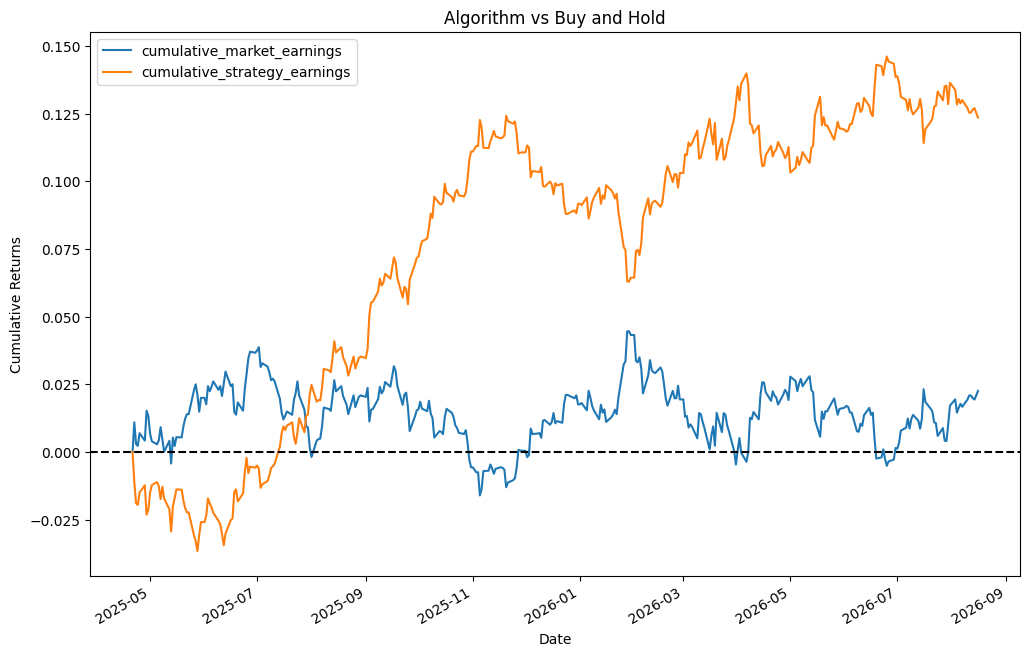

In [19]:
# Visualisation of Strategy Returns against Buy and Hold Returns
ax = backtester[["cumulative_market_earnings", "cumulative_strategy_earnings"]].plot(figsize=(12,8), title = "Algorithm vs Buy and Hold")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Returns")
ax.axhline(y=0, color="black", linestyle = "--")


#print(backtester)


In [20]:
# Checking which c value is the best

c_values = [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 100]

for c in c_values:
    test_model = LogisticRegression(C=c)
    test_model.fit(x_train, y_train)
    test_prediction = test_model.predict(x_test)
    test_accuracy = accuracy_score(y_test, test_prediction)
    print(f"C = {c} \nAccuracy = {test_accuracy * 100:.3f}%\n")


C = 0.001 
Accuracy = 54.000%

C = 0.01 
Accuracy = 54.000%

C = 0.1 
Accuracy = 53.714%

C = 0.5 
Accuracy = 54.000%

C = 1 
Accuracy = 56.571%

C = 5 
Accuracy = 60.571%

C = 10 
Accuracy = 60.571%

C = 100 
Accuracy = 60.857%



In [21]:
# OLS compares today's interest rate spread against today's fx returns
# Note: We don't lag as we're not predicting but explaining real time results of changing interest rate spread on fx returns  

macro_data["rate_diff_change"] = macro_data["Rate_Diff"].diff()

ols_df = macro_data[["rate_diff_change", "FX_Returns"]].dropna().copy()
ols_df = ols_df[ols_df["rate_diff_change"] != 0.0]
x_spread = sm.add_constant(ols_df["rate_diff_change"])
y_returns = ols_df["FX_Returns"] * 100

ols_model = sm.OLS(y_returns, x_spread).fit()

spread_coef = ols_model.params["rate_diff_change"]


print(f"Historically on average we can see that an increase of 1% in the US-UK interest rate spread leads to an average decrease of {spread_coef:.2f}% in the GBP/USD")

ols_df.to_excel("FX_dashboard.xlsx")

#print(spread_coef)
#print(ols_model.summary())
#print(ols_df)


Historically on average we can see that an increase of 1% in the US-UK interest rate spread leads to an average decrease of -0.29% in the GBP/USD


In [22]:
# Cell to export data to excel spreadsheet

workbook = openpyxl.load_workbook("FX_dashboard.xlsx")

data_sheet = workbook.worksheets[0]
data_sheet.title = "Raw Data"

data_sheet.column_dimensions["A"].width = 25

if "Dashboard" in workbook.sheetnames:
    del workbook["Dashboard"]

dashboard_sheet = workbook.create_sheet(title="Dashboard")

# 1 bps = 0.01% (e.g bps of 25 is 0.25%)
dashboard_sheet["A1"] = "Bank of England Interest Rate (bps):"
dashboard_sheet["A2"] = "Fed Reserve Interest Rate (bps):"
dashboard_sheet["A4"] = "Net Spread Change:"
dashboard_sheet["A5"] = f"Expected move in GBP/USD (FX Sensitivity: {spread_coef:.2f}%):"

dashboard_sheet["B1"] = 0
dashboard_sheet["B2"] = 25
dashboard_sheet["B4"] = "=B2-B1"

dashboard_sheet["B5"] = f"=(B4/100)*{spread_coef}"

dashboard_sheet["A6"] = "Trade Direction (Buy = 1, Sell = -1):"
dashboard_sheet["B6"] = 1

dashboard_sheet["A7"] = f"Enter trade size (£):"
dashboard_sheet["B7"] = 10000000
dashboard_sheet["A8"] = "Trading P&L:"

dashboard_sheet["B8"] = "=(B5/100) * B7 * B6"

# Iterates through this list and makes the cell bold
for cell in ["A1", "A2", "A4", "A5", "A6", "A7", "A8"]:
    dashboard_sheet[cell].font = Font(bold=True)

# Modifies column width
dashboard_sheet.column_dimensions["A"].width = 45
dashboard_sheet.column_dimensions["B"].width = 20

workbook.save("FX_dashboard.xlsx")

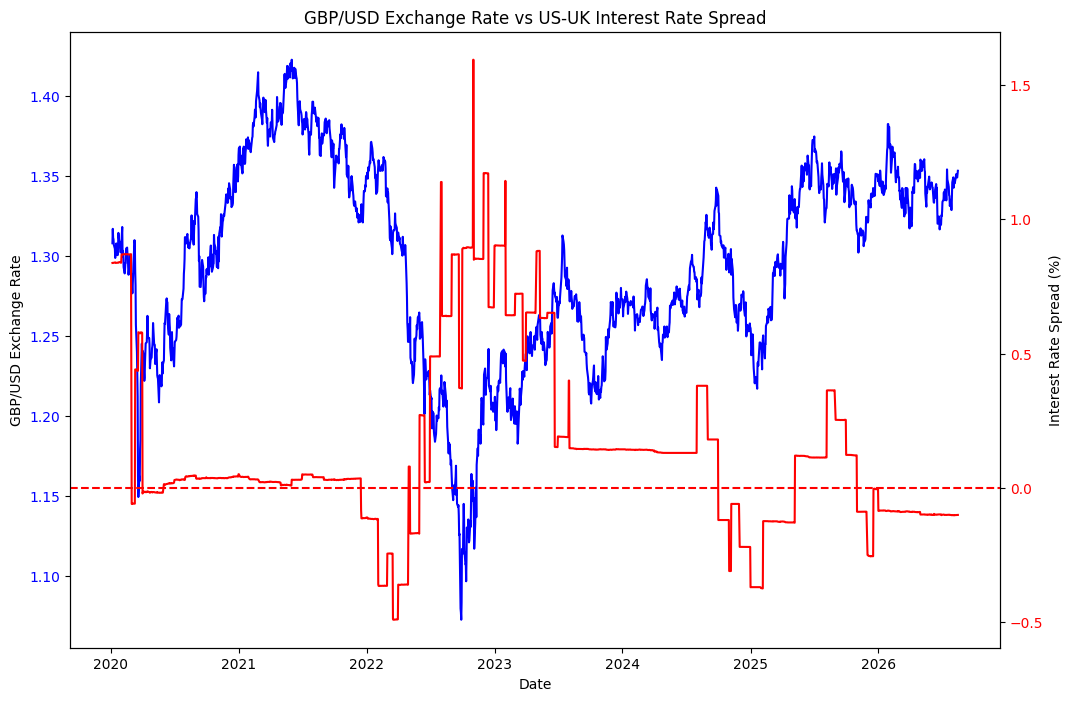

In [23]:
fig, ax1 = plt.subplots(figsize=(12, 8))

ax1.plot(macro_data.index, macro_data["GBP_USD"], color="blue")
ax1.set_xlabel("Date")
ax1.set_ylabel("GBP/USD Exchange Rate")
ax1.tick_params(axis="y", labelcolor="blue")

# This essentially layers a second axis on top of ax1
ax2 = ax1.twinx()
ax2.plot(macro_data.index, macro_data["Rate_Diff"], color="red")
ax2.set_ylabel("Interest Rate Spread (%)")
ax2.tick_params(axis="y", labelcolor="red")
ax2.axhline(y=0, linestyle = "--", color="red")

plt.title("GBP/USD Exchange Rate vs US-UK Interest Rate Spread")

plt.show()


In [24]:
# Code to isolate lagged rate diff (Modules: pandas and statsmodel.api)

x = macro_data["Lagged_Rate_Diff"]
x = sm.add_constant(x)

y = macro_data["FX_Returns"]

results = sm.OLS(y, x).fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:             FX_Returns   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.8196
Date:                Sun, 16 Aug 2026   Prob (F-statistic):              0.365
Time:                        18:10:22   Log-Likelihood:                 6635.2
No. Observations:                1748   AIC:                        -1.327e+04
Df Residuals:                    1746   BIC:                        -1.326e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -2.014e-05      0.000  